In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import healpy as hp

# 1Mhz

In [2]:
NSIDE = 512
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

Approximate resolution at NSIDE 512 is 0.11 deg


In [3]:
NPIX = hp.nside2npix(NSIDE)
print(NPIX)

3145728


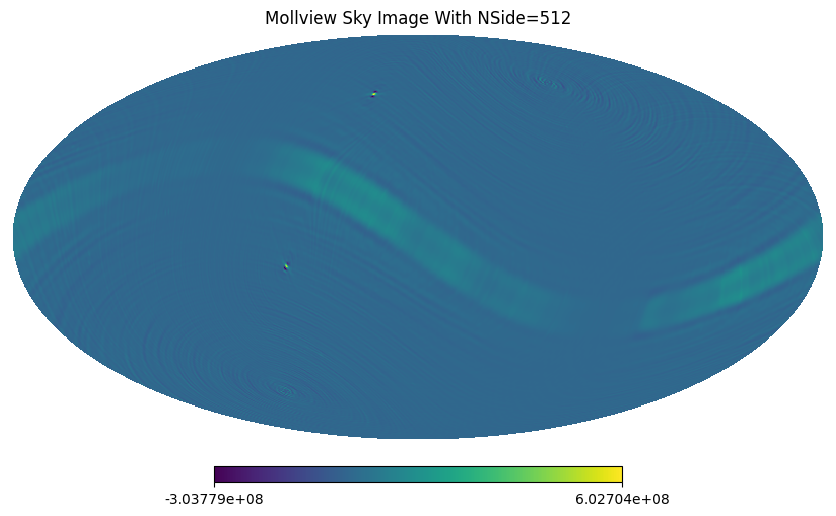

In [4]:
recon = np.fromfile("./out1M/C1day1M.bin", dtype=np.float32)

hp.mollview(recon, 
            title="Mollview Sky Image With NSide=512")
plt.show()

# 10Mhz

In [2]:
NSIDE = 4096
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)
NPIX = hp.nside2npix(NSIDE)
print(NPIX)

Approximate resolution at NSIDE 4096 is 0.014 deg
201326592


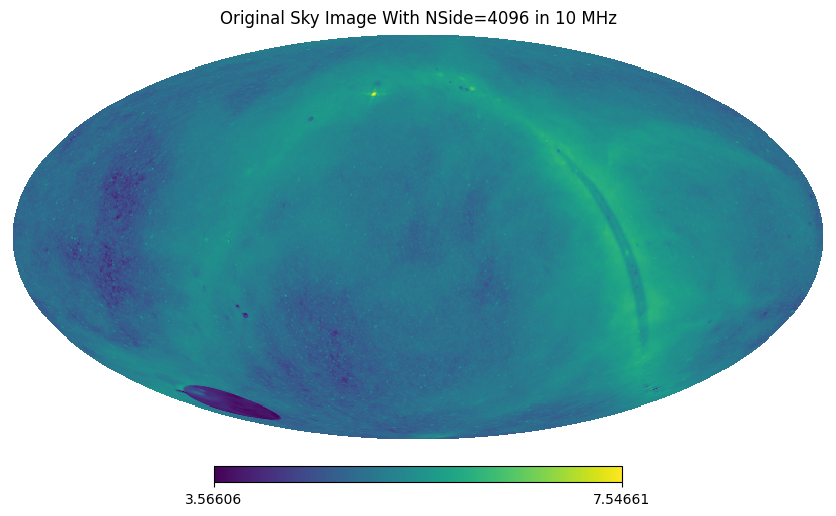

In [3]:
origin10m = np.fromfile("../input_skymap/sky_sao/10M_n4096_ring_ecliptic/B_10M.bin", dtype=np.float32)

hp.mollview(np.log10(origin10m), 
            title="Original Sky Image With NSide=4096 in 10 MHz")
plt.show()

/tmp/ipykernel_1925253/1960777897.py:3: RuntimeWarning: invalid value encountered in log10
  hp.mollview(np.log10(recon10m),


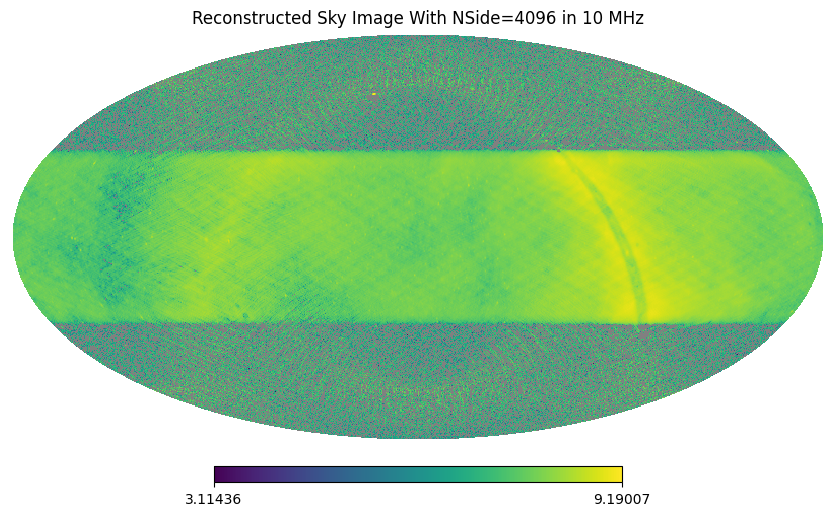

In [4]:
recon10m = np.fromfile("./out10M/C_accum_10M_days1_450.bin", dtype=np.float32)

hp.mollview(np.log10(recon10m), 
            title="Reconstructed Sky Image With NSide=4096 in 10 MHz")
plt.show()

In [5]:
import numpy as np
import healpy as hp
from skimage.metrics import structural_similarity as ssim

def linear_calibrate(ref, pred, mask):
    x = pred[mask].astype(np.float64)
    y = ref[mask].astype(np.float64)
    A = np.vstack([x, np.ones_like(x)]).T
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return a * pred + b, a, b

def metrics(ref, pred, mask):
    ref_m = ref[mask].astype(np.float64)
    pred_m = pred[mask].astype(np.float64)

    pearson = np.corrcoef(ref_m, pred_m)[0, 1]
    cosine = np.dot(ref_m, pred_m) / (np.linalg.norm(ref_m) * np.linalg.norm(pred_m) + 1e-30)
    nrmse = np.sqrt(np.mean((ref_m - pred_m) ** 2)) / (ref_m.max() - ref_m.min() + 1e-30)

    return pearson, nrmse, cosine

nside = 4096
origin = origin10m.astype(np.float64)
recon = recon10m.astype(np.float64)

# 防止 log 出问题
origin_log = np.log10(np.maximum(origin, 1e-30))
recon_log = np.log10(np.maximum(recon, 1e-30))

npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix), nest=False)

# latitude = pi/2 - theta
lat = np.pi / 2 - theta

full_mask = np.isfinite(origin_log) & np.isfinite(recon_log)
band_mask = full_mask & (np.abs(lat) <= np.deg2rad(30))

recon_cal, a, b = linear_calibrate(origin_log, recon_log, band_mask)

print("linear calibration: origin_log ≈ a * recon_log + b")
print("a =", a, "b =", b)

print("Full sky:", metrics(origin_log, recon_cal, full_mask))
print("Band |lat|<=30:", metrics(origin_log, recon_cal, band_mask))

linear calibration: origin_log ≈ a * recon_log + b
a = 0.07437099971155327 b = 4.6294554722860175
Full sky: (np.float64(0.04309883519302297), np.float64(0.3416719767006654), np.float64(0.9653091621253426))
Band |lat|<=30: (np.float64(0.3134840405573675), np.float64(0.1270022331467497), np.float64(0.9982531027761017))
